# Imports

In [1]:
from importlib import reload
import ActivationPrototypes_SARSeg.thesis_utils as utils
reload(utils)
from ActivationPrototypes_SARSeg.thesis_utils import *
from torch.utils.data import DataLoader

2025-02-07 01:39:00.508 | INFO     | ActivationPrototypes_SARSeg.config:<module>:11 - PROJ_ROOT path is: F:\Thesis\ActivationPrototypes_SARSeg
c:\Users\Jean\anaconda3\envs\ActivationPrototypes_SARSeg\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lmdb_path = "F:\\Thesis\\Datasets\\Big Earth\\Encoded-BigEarthNet"
parquet_path = "F:\\Thesis\Datasets\\Big Earth\\metadata.parquet"

model128 = load_from_checkpoint("../models/unet_epoch_20.pth").to(device)
model120 = load_from_checkpoint120("../models/first_try/unet120_epoch_2.pth").to(device)
model_untrained = load_base_with_bigearth_pretrained120().to(device)
model_120short = load_from_checkpoint120("../models/short10k/unet120_10k_epoch_10.pth").to(device)
model_120_full = load_from_checkpoint120("../models/full_120/unet120_full_epoch_20.pth").to(device)

indices = [458, 155, 163, 424, 396]

In [4]:
# Create datasets

train_matches, val_matches, test_matches = match_keys(parquet_path)	
train_dataset = SARSegmentationDataset120(lmdb_path, train_matches[:], transform=None)
val_dataset = SARSegmentationDataset120(lmdb_path, val_matches[:], transform=None)
test_dataset = SARSegmentationDataset120(lmdb_path, test_matches[:], transform=None)

train_dataset128 = SARSegmentationDataset(lmdb_path, train_matches[:], transform=None)
val_dataset128 = SARSegmentationDataset(lmdb_path, val_matches[:], transform=None)
test_dataset128 = SARSegmentationDataset(lmdb_path, test_matches[:], transform=None)

# Create data loaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

train_loader128 = DataLoader(train_dataset128, batch_size=batch_size, shuffle=True)
val_loader128 = DataLoader(val_dataset128, batch_size=batch_size, shuffle=False)
test_loader128 = DataLoader(test_dataset128, batch_size=batch_size, shuffle=False)

Opening LMDB environment ...
Opening LMDB environment ...
Opening LMDB environment ...
Opening LMDB environment ...
Opening LMDB environment ...
Opening LMDB environment ...


# Inference

## 128x128

In [5]:
test_loss, test_iou, test_f1 = calculate_scores(model128, test_loader128, device, 20)

Calculating scores:   0%|          | 0/7490 [00:00<?, ?it/s]c:\Users\Jean\anaconda3\envs\ActivationPrototypes_SARSeg\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
Calculating scores: 100%|██████████| 7490/7490 [06:36<00:00, 18.87it/s]

Test Loss: 2.5032895988074735, Test IoU: 0.46007430060046695, Test F1: 0.603798395928458


[458, 155, 163, 424, 396]
Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_50_50, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_50_50_reference_map


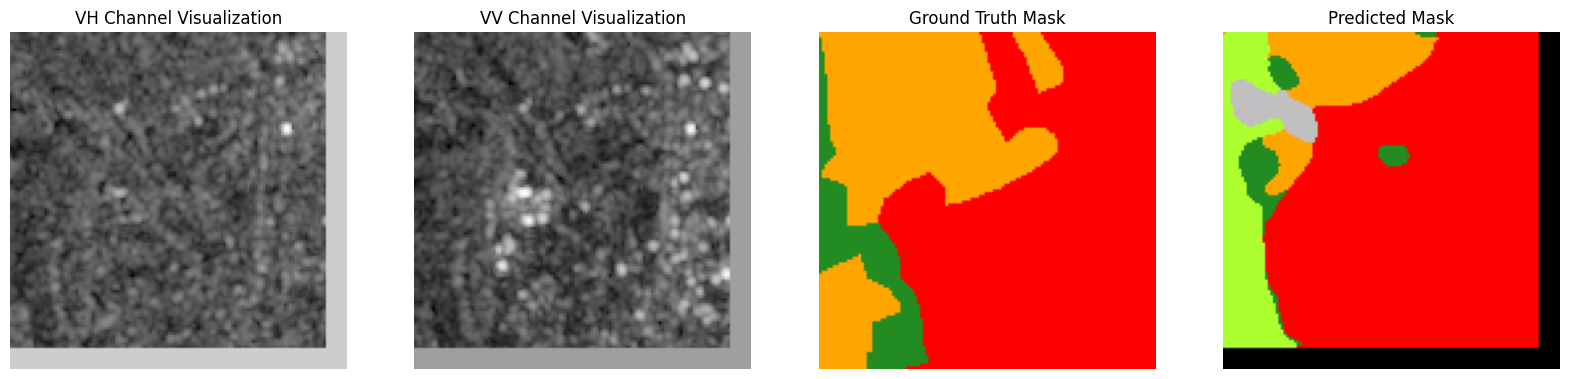

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_37_59, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_59_reference_map


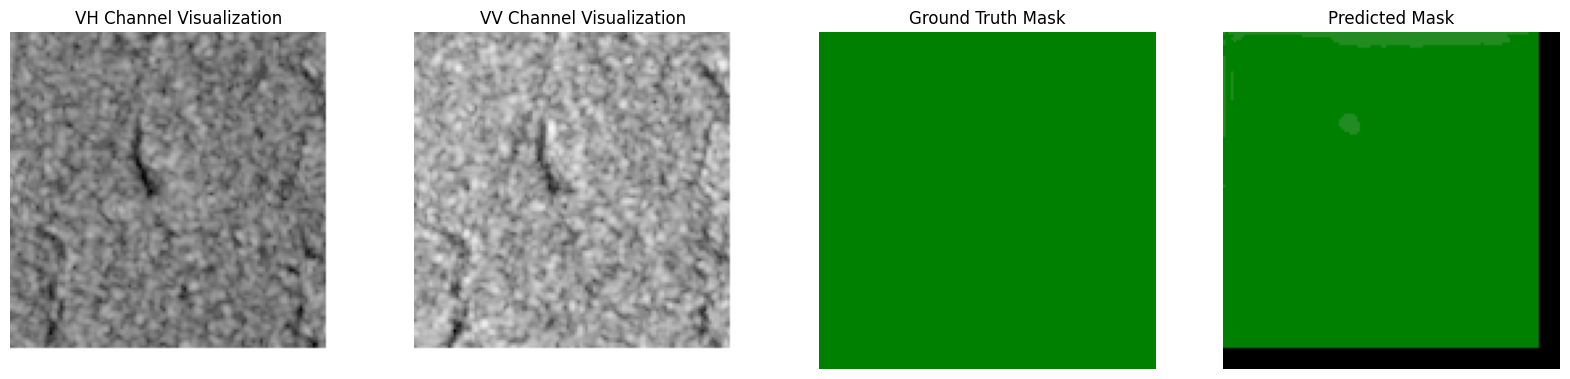

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_37_67, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_67_reference_map


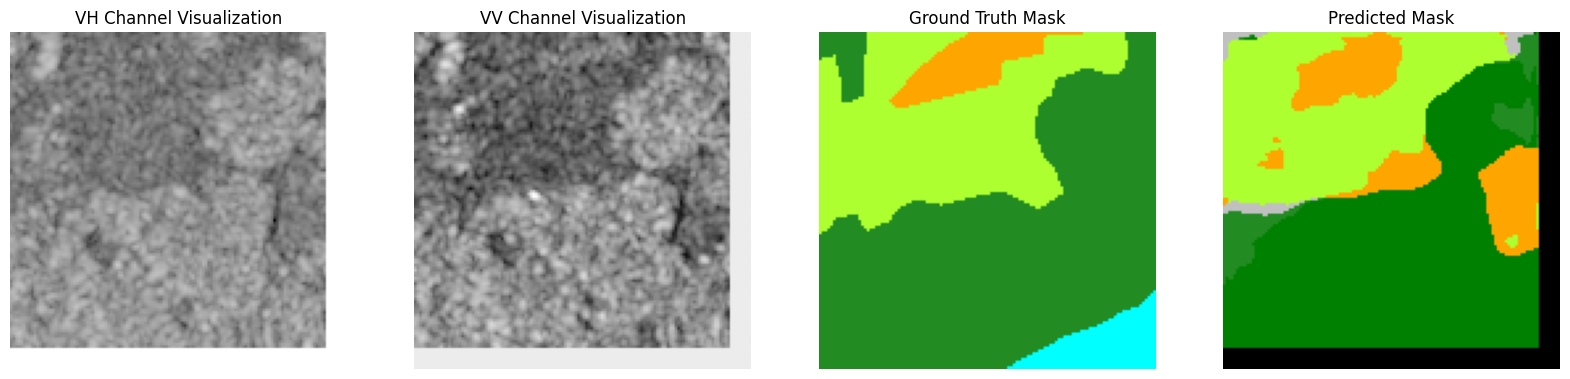

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_49_42, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_49_42_reference_map


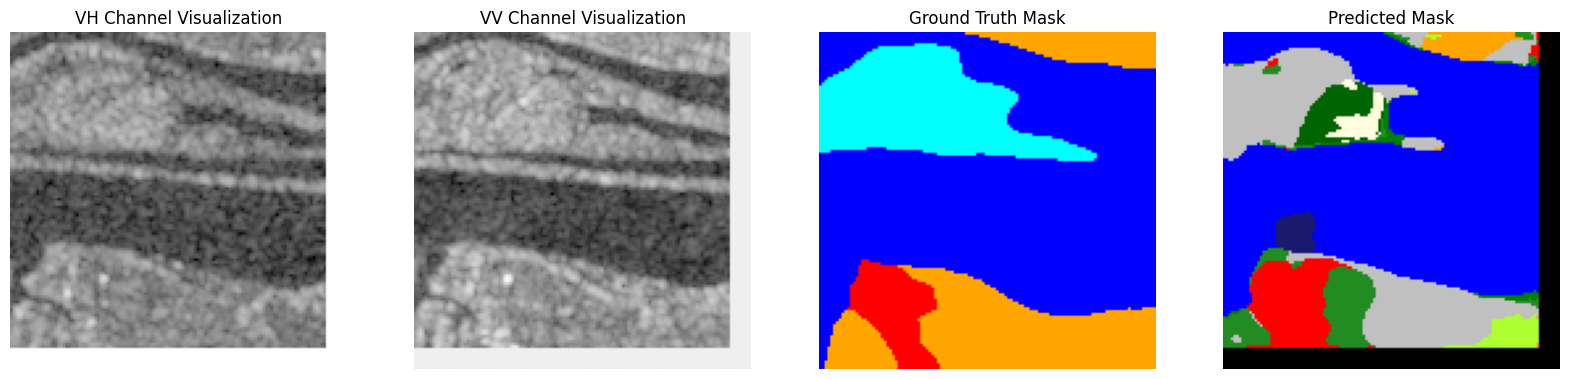

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_47_68, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_47_68_reference_map


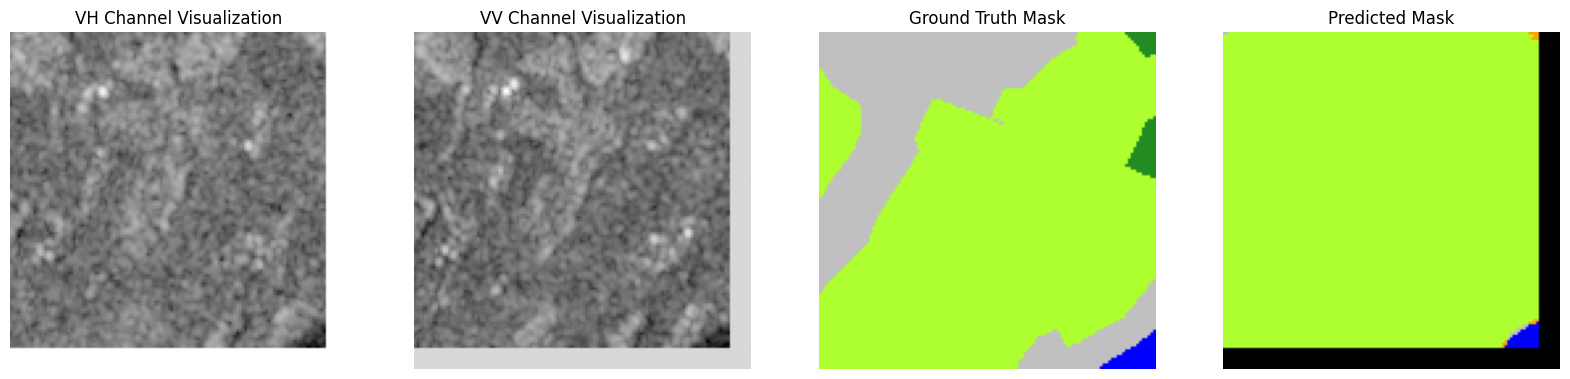

In [6]:
display_results(model128, test_loader128, lmdb_path, num_images=5, indices = indices)

## 120x120

In [7]:
test_loss, test_iou, test_f1 = calculate_scores(model_120_full, test_loader, device, 20)

Calculating scores: 100%|██████████| 7490/7490 [05:57<00:00, 20.97it/s]

Test Loss: 2.512218292596662, Test IoU: 0.4437937946540014, Test F1: 0.5828587086659884


[458, 155, 163, 424, 396]
Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_50_50, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_50_50_reference_map


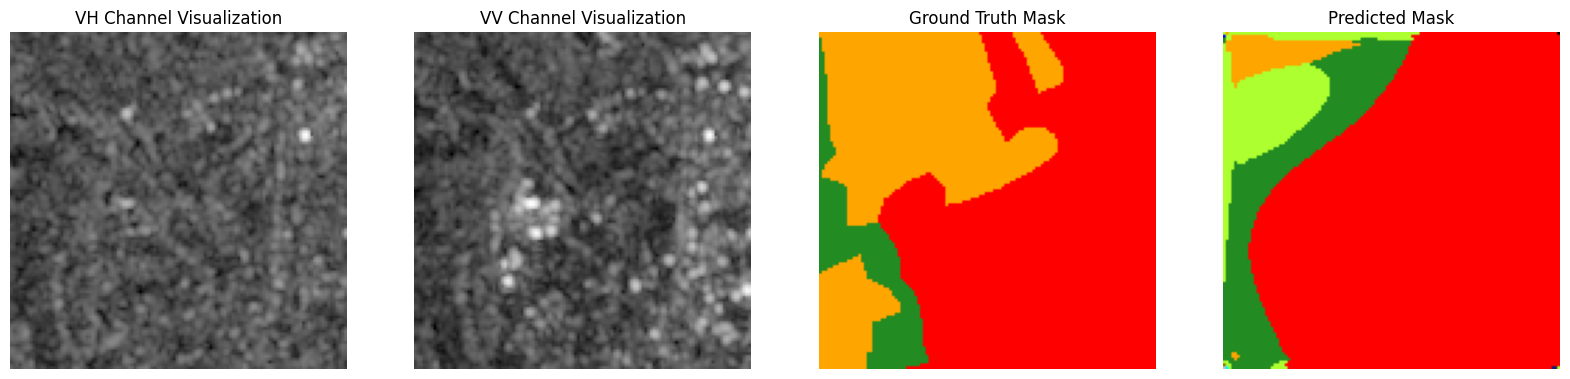

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_37_59, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_59_reference_map


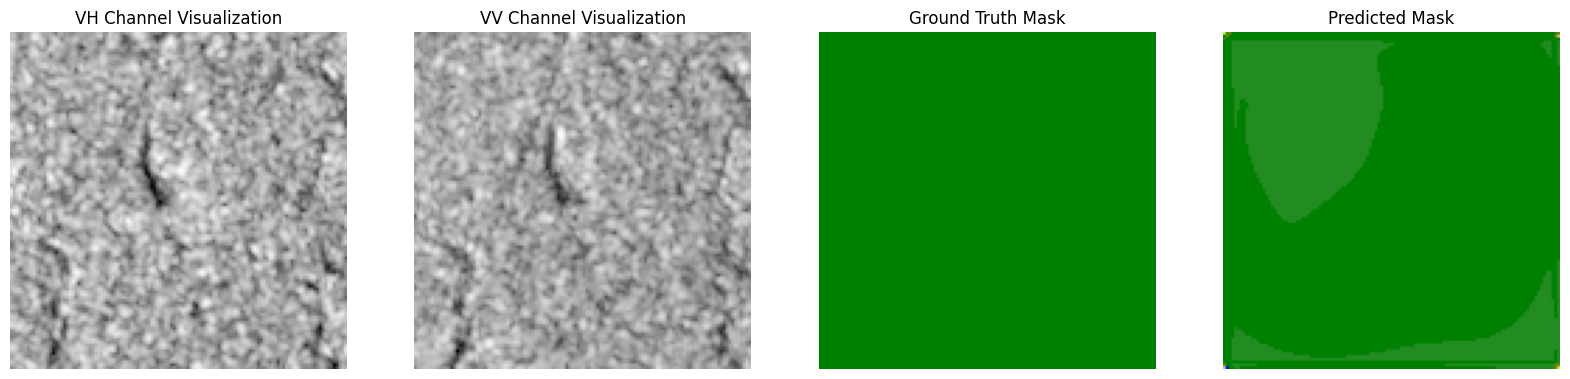

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_37_67, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_67_reference_map


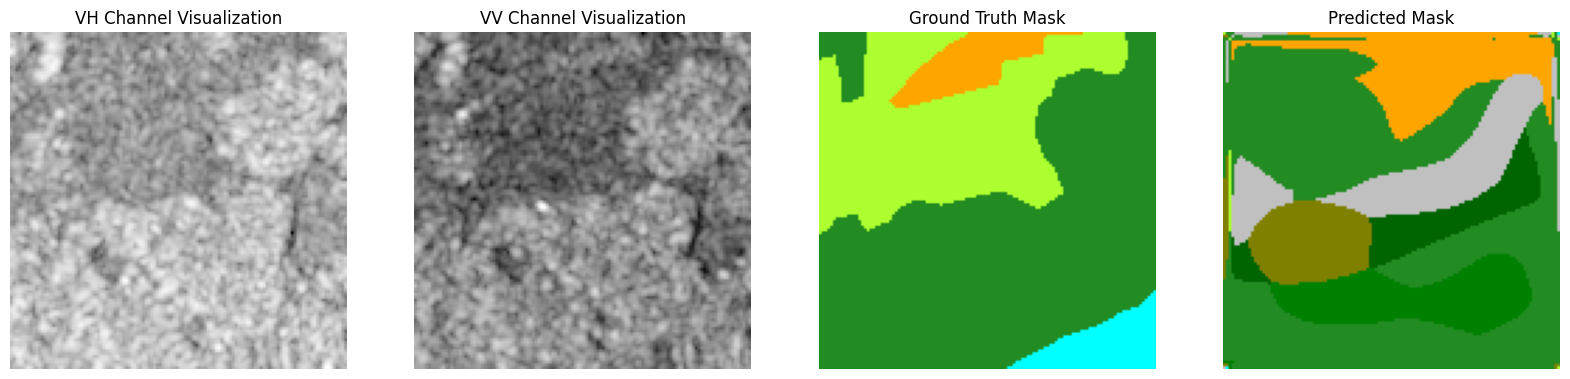

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_49_42, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_49_42_reference_map


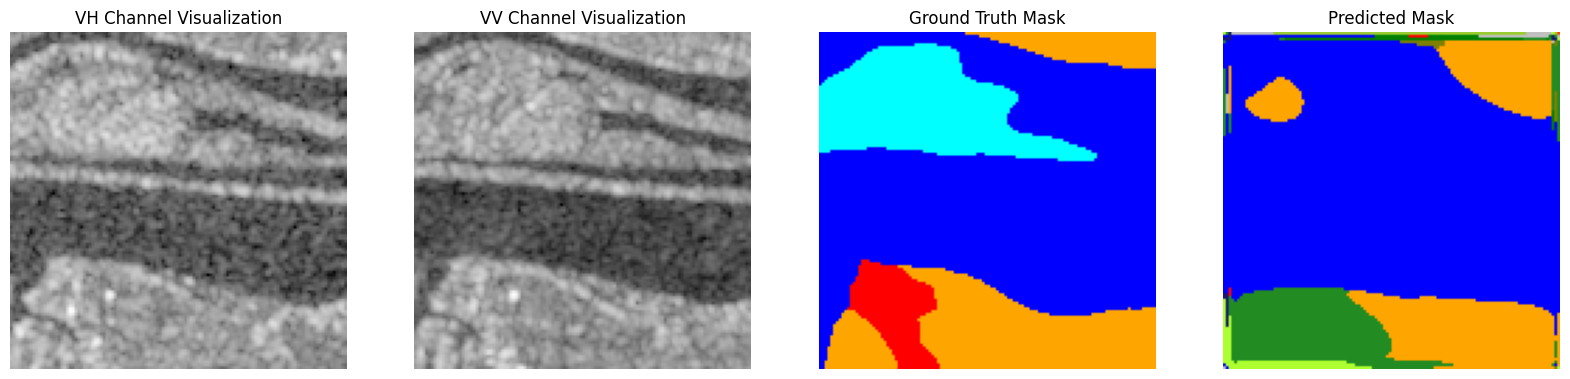

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_47_68, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_47_68_reference_map


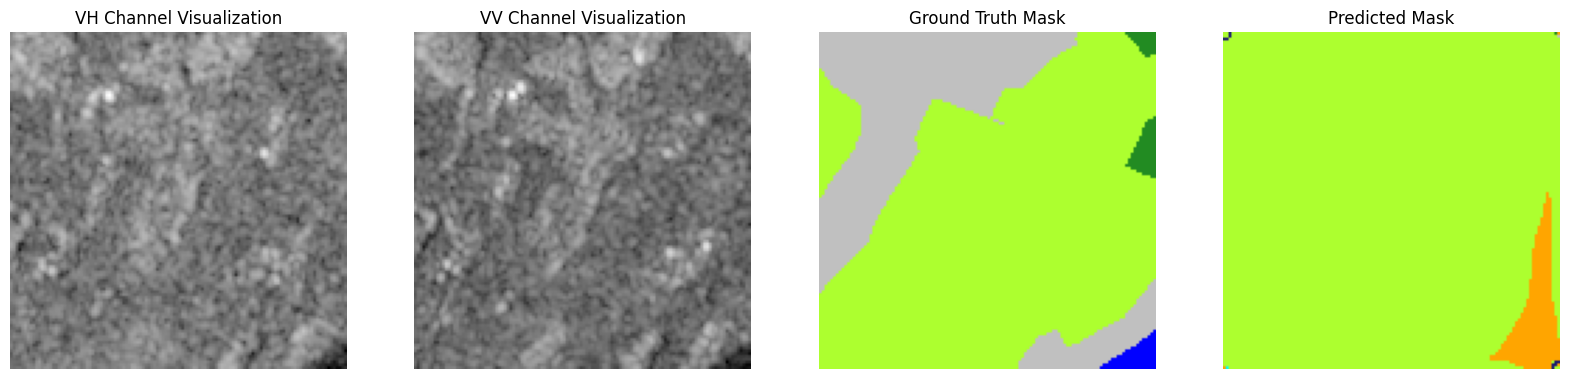

In [8]:
display_results(model120, test_loader, lmdb_path, num_images=5, indices = indices)

## 120x120 short

In [9]:
test_loss, test_iou, test_f1 = calculate_scores(model_120short, test_loader, device, 20)

Calculating scores: 100%|██████████| 7490/7490 [05:13<00:00, 23.86it/s]

Test Loss: 2.6699033209733236, Test IoU: 0.32437716505906256, Test F1: 0.44322260810347675


[458, 155, 163, 424, 396]
Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_50_50, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_50_50_reference_map


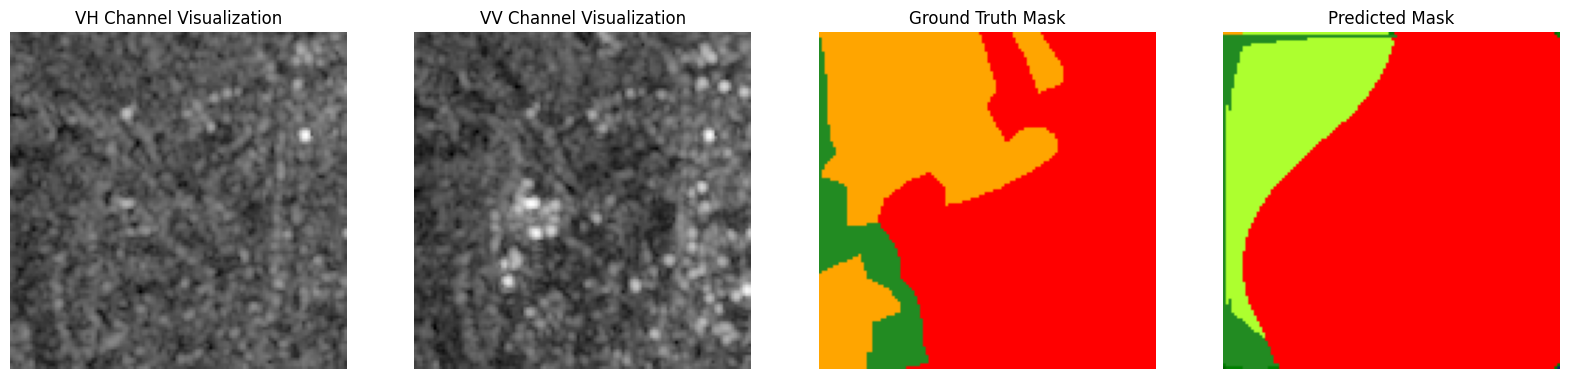

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_37_59, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_59_reference_map


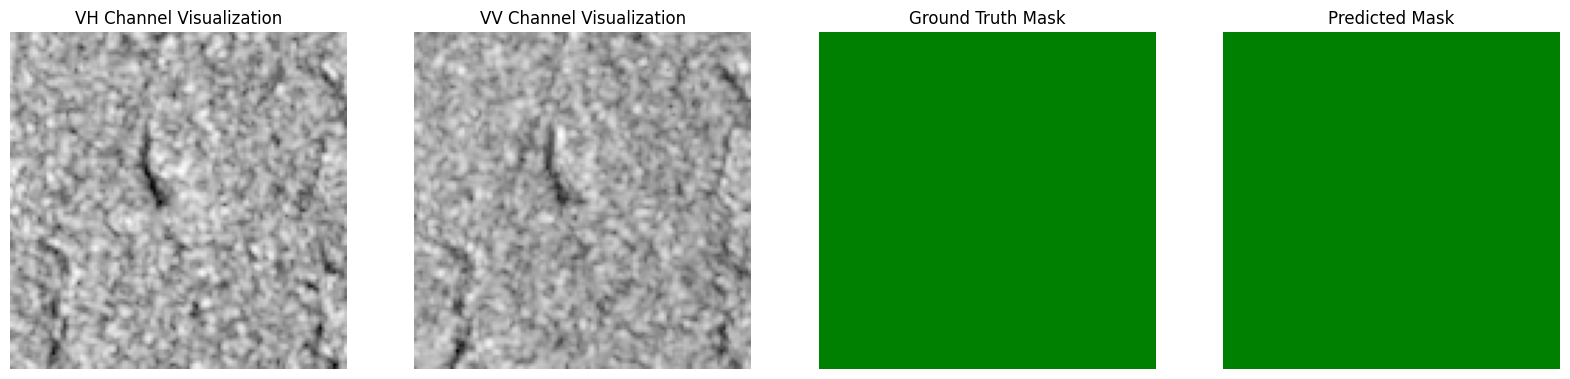

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_37_67, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_67_reference_map


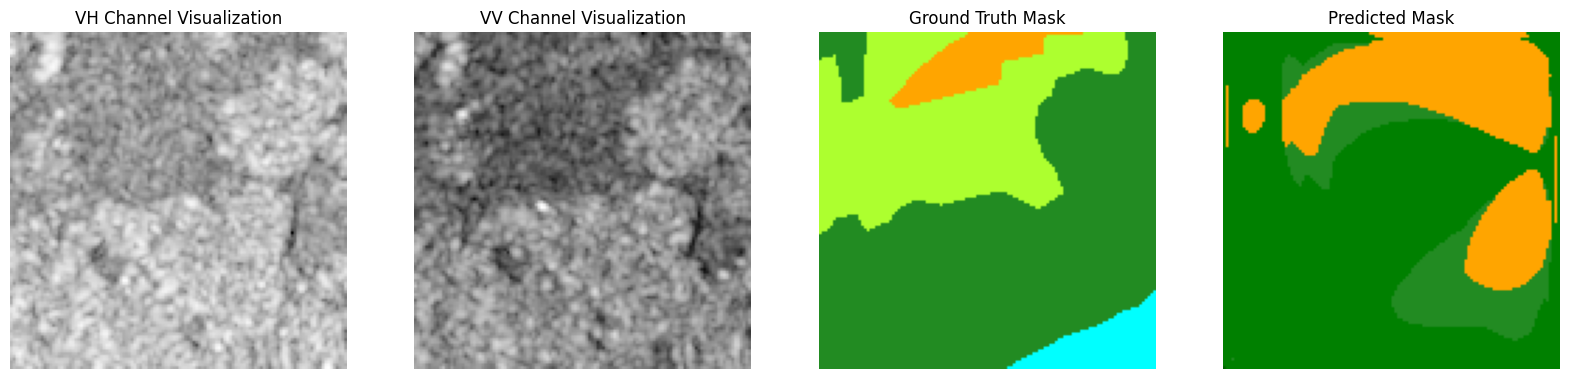

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_49_42, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_49_42_reference_map


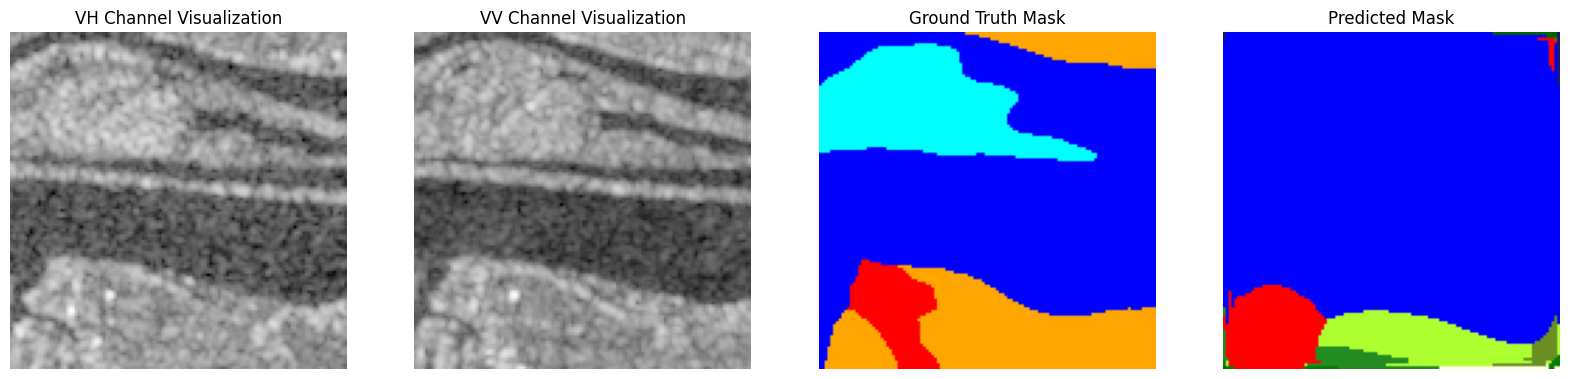

Image Key: S1B_IW_GRDH_1SDV_20170612T165809_33UUP_47_68, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_47_68_reference_map


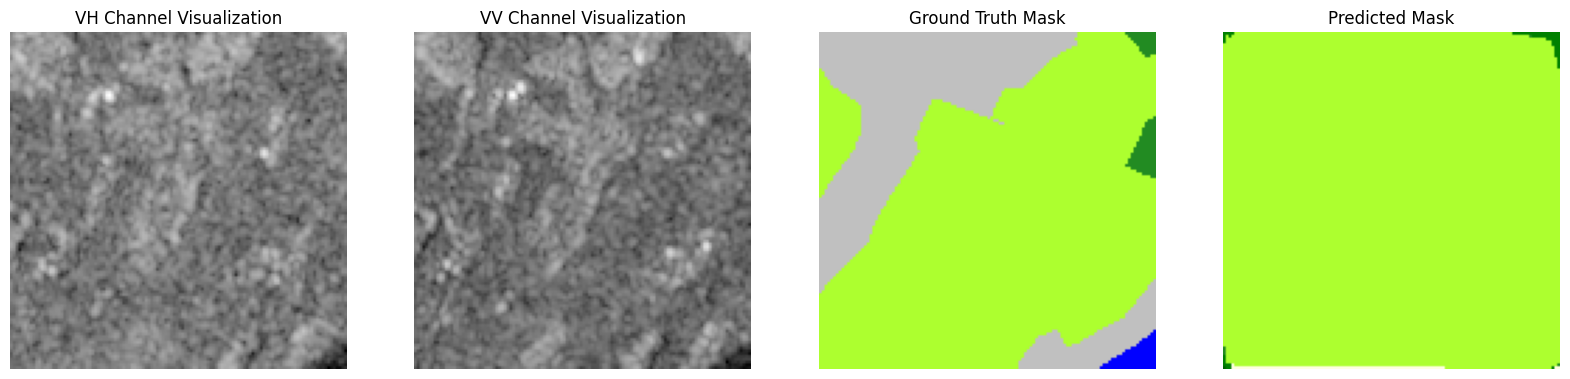

In [10]:
display_results(model_120short, test_loader, lmdb_path, num_images=5, indices = indices)

## Untrained 120x120

In [35]:
test_loss, test_iou, test_f1 = calculate_scores(model_untrained, test_loader, device, 20)

Calculating scores:   0%|          | 0/7490 [00:00<?, ?it/s]c:\Users\Jean\anaconda3\envs\ActivationPrototypes_SARSeg\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
Calculating scores: 100%|██████████| 7490/7490 [09:02<00:00, 13.82it/s] 

Test Loss: 2.9957285266056237, Test IoU: 0.04165951707474295, Test F1: 0.07435968732132507


[96231]
Image Key: S1A_IW_GRDH_1SDV_20180421T165021_33TWN_61_58, Reference Key: S2B_MSIL2A_20180421T100029_N9999_R122_T33TWN_61_58_reference_map


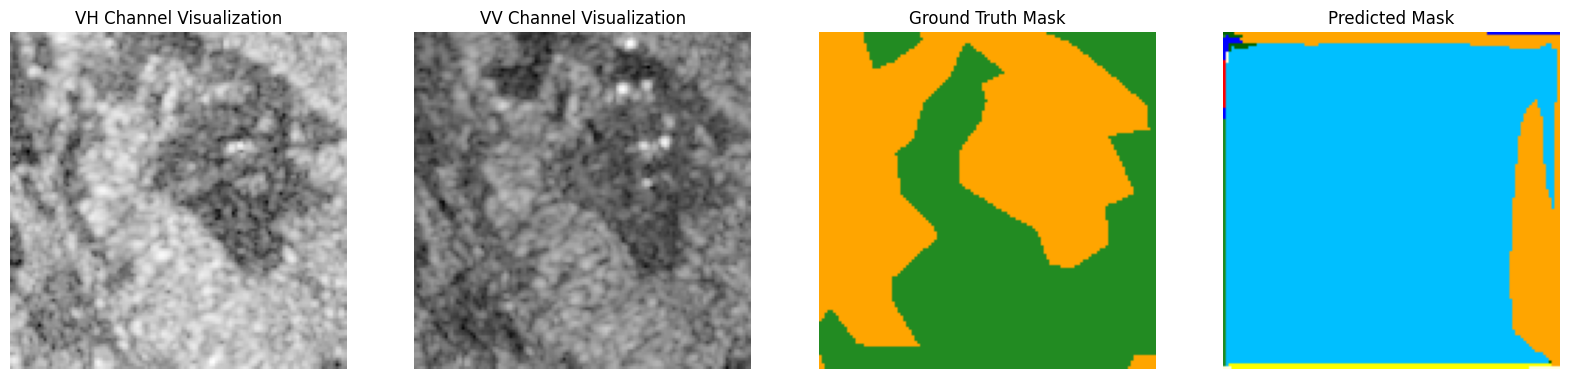

In [38]:
display_results(model_untrained, test_loader, lmdb_path, num_images=1)